In [2]:
import numpy as np
import pickle
import torch
import time
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.learning as lrn
from src.safetymaps import *
from src.reachsteering import HdaGreedy, HdaReachSteering
from src.visualization import *
%load_ext autoreload
%autoreload 2
%matplotlib inline

C:\Users\ktomita3\.conda\envs\pygmo3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def visualize_traj(hda):
    t, X, U = hda.construct_trajectory()
    fig, axs = plot_3sides(t[:-1], X, U=None, uskip=1)
    n_traj = len(hda.X_list)
    for i in range(n_traj):
        t_ = hda.t_list[i]
        X_ = hda.X_list[i]
        U_ = hda.U_list[i]
        fig, axs = plot_3sides(t_[:-1], X_, U=None, uskip=1, fig=fig, axs=axs, linetype='k:')

        axs[0, 0].scatter(X_[0, 0], X_[0, 1], marker='o', color='r')
        axs[1, 0].scatter(X_[0, 0], X_[0, 2], marker='o', color='r')
        axs[1, 1].scatter(X_[0, 1], X_[0, 2], marker='o', color='r')

    # tight layout
    plt.tight_layout()

    return fig, axs

def visualize_profiles(hda, lander):
    t, X, U = hda.construct_trajectory()
    plot_vel(t, X, lander.vmax)
    plot_mass(t, X, lander.mdry, lander.mwet)
    plot_thrust_mag(t[:-1], U, lander.rho2, lander.rho1)
    plot_pointing(t[:-1], U, lander.pa)
    

In [4]:
def visualize_nn_reach(hda, n_skip=1, fontsize=16):
    # make font times new roman
    plt.rcParams["font.family"] = "Times New Roman"

    sfmap_list = hda.sfmap_list[1:]
    reach_mask_list = hda.reachmask_list
    t_list = hda.t_list

    # skip
    sfmap_list = sfmap_list[::n_skip]
    reach_mask_list = reach_mask_list[::n_skip]
    t_list = t_list[::n_skip]
    # print their len
    print(f'Number of maps: {len(sfmap_list)}')
    print(f'Number of reachability masks: {len(reach_mask_list)}')
    print(f'Number of time steps: {len(t_list)}')
    

    n_map = len(sfmap_list) 
    fig, axs = plt.subplots(1, n_map, figsize=(5*n_map, 6), sharey=True, sharex=True)
    for i in range(n_map):

        sfmap = sfmap_list[i]
        reach_mask = reach_mask_list[i]
        t = t_list[i][0]
    

        n = int(np.sqrt(sfmap.shape[0]))

        x = sfmap[:, 0].reshape(n, n)
        y = sfmap[:, 1].reshape(n, n)
        safety = sfmap[:, 2].reshape(n, n)
        reach_mask = reach_mask.reshape(n, n)

        # Safety Map
        safety_img = axs[i].pcolormesh(x, y, safety, shading='auto', cmap='gray', vmin=0, vmax=1)
        #plt.colorbar(safety_img, ax=axs[i], orientation='vertical', label='Safety')

        # Reachability Set - as the overlay with transparency
        reach_mask[reach_mask <= 0.4] = np.nan
        reachability_img = axs[i].pcolormesh(x, y, reach_mask, shading='auto', cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.colorbar(reachability_img, ax=axs[i], orientation='vertical', label='Reachability')

        axs[i].set_title(f't={t:.0f} s', fontsize=fontsize)
        if i == 0:
            axs[i].set_ylabel('y, m', fontsize=fontsize)
        axs[i].set_xlabel('x, m', fontsize=fontsize)
        axs[i].set_aspect('equal')
        # set font size
        axs[i].tick_params(labelsize=fontsize)


    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([1.0, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    fig.colorbar(safety_img, ax=axs[-1], cax=cbar_ax)
    # colorbar ticks font size
    cbar_ax.tick_params(labelsize=fontsize)
    # colorbar label
    cbar_ax.set_ylabel("Safety", rotation=270, labelpad=20, fontsize=fontsize)
    # tight layout
    plt.tight_layout()
    return fig, axs

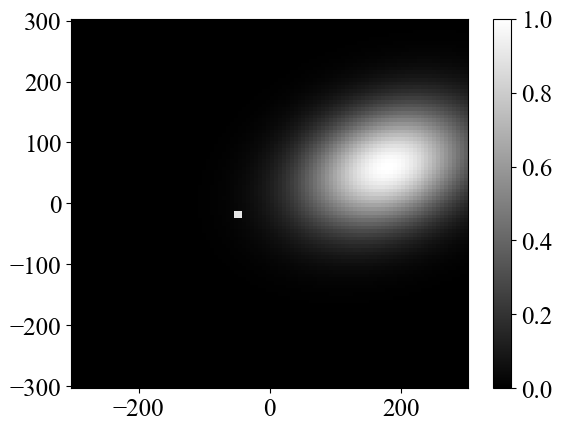

In [5]:
with open('../saved/controllable_set/lander.pkl', 'rb') as f:
        lander = pickle.load(f)

hidden_layers = [256, 256, 256]
nn_reach = lrn.NeuralReach(hidden_layers=hidden_layers)
#nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20231130-175526/mlp_reach/mlp_reach.pt'))
nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20240808-162255/mlp_reach/mlp_reach.pt'))
nn_reach.eval()

sfmap_model = StaticSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
#sfmap_model = DynamicSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100, relative_path="..")
#sfmap_model = StaticNoisedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
#sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100, n_hazards=[50, 50, 400, 2000, 2000], hazard_sizes=[14, 12,  8, 5, 2])
#sfmap_model = DynamicSafetyMap2(x_range=(-300, 300), y_range=(-300, 300), npoints=500, relative_path='../')


#x0_init = np.array([0.0, 0.0, 1400.0, 5, -10, -35.0, lander.mwet])
x0_init = np.array([0.0, 0.0, 1300.0, 0.0, -5, -55.0, lander.mwet])
x0_init = np.array([-120.0, 0.0, 1300.0, 10.0, 5, -55.0, lander.mwet])
tof = 60.0
T = 5.0
dt = 0.5

In [58]:
hda_greedy = HdaGreedy(lander, sfmap_model, nn_reach, border_sharpness=10.0)
hda_greedy.solve_hda(x0_init, tof, T, dt)

x0: [-120.    0. 1300.   10.    5.  -55. 1905.], tgo: 60.0
Greedy HDA optimized single leg: 1.8589684963226318 sec
x0: [ -77.70401978   20.11601145 1065.53152635    6.96592135    3.08169368
  -38.68902081 1874.97621678], tgo: 55.0
Greedy HDA optimized single leg: 1.4849042892456055 sec
x0: [-4.98479305e+01  3.11826827e+01  9.14109214e+02  4.22572959e+00
  1.38150677e+00 -2.17792157e+01  1.84495662e+03], tgo: 50.0
Greedy HDA optimized single leg: 1.390425682067871 sec
x0: [-3.47044207e+01  3.43100971e+01  8.48755643e+02  1.87985296e+00
 -9.27129181e-02 -4.25952470e+00  1.81494889e+03], tgo: 45.0
Greedy HDA optimized single leg: 1.231846809387207 sec
x0: [-2.78541476e+01  3.22877879e+01  8.25083322e+02  9.91075707e-01
 -6.32403465e-01 -7.04272484e+00  1.80199241e+03], tgo: 40.0
Greedy HDA optimized single leg: 1.0939879417419434 sec
x0: [-2.45591658e+01  2.81626754e+01  7.77990255e+02  3.47290146e-01
 -1.00192236e+00 -1.17818101e+01  1.79072668e+03], tgo: 35.0
Greedy HDA optimized single

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_10304\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


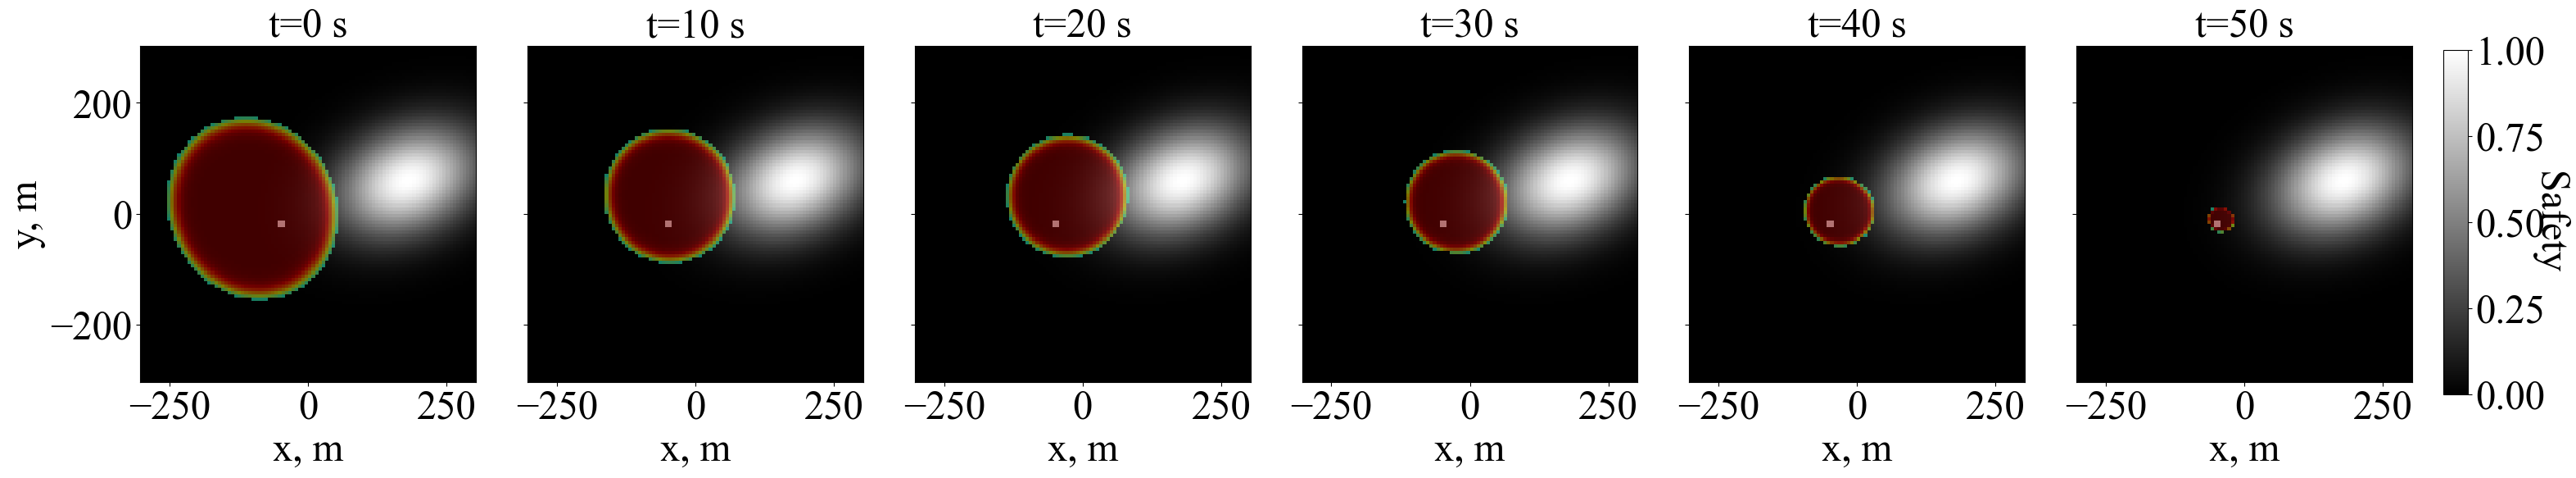

In [59]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)

x0: [-120.    0. 1300.   10.    5.  -55. 1905.], tgo: 60.0
Initial guess: 1.8143553733825684 sec for 1 solutions
Reach-steering HDA optimized single leg: 29.88162088394165 sec
x0: [ -64.41509918   25.96043134 1019.10484166   11.71843102    5.29551734
  -58.23720308 1891.41313305], tgo: 55.0
Initial guess: 1.5261549949645996 sec for 1 solutions
Reach-steering HDA optimized single leg: 8.66060471534729 sec
x0: [-1.01933552e+00  5.19212939e+01  7.19194492e+02  1.34651978e+01
  5.10761767e+00 -6.18831964e+01  1.87826831e+03], tgo: 50.0
Initial guess: 1.4496879577636719 sec for 1 solutions
Reach-steering HDA optimized single leg: 19.24921226501465 sec
x0: [ 5.20251386e+01  6.79306274e+01  4.50342086e+02  7.97351822e+00
  1.51829155e+00 -4.55040829e+01  1.84822369e+03], tgo: 45.0
Initial guess: 1.3179559707641602 sec for 1 solutions
Reach-steering HDA optimized single leg: 336.56042742729187 sec
x0: [ 8.41932909e+01  7.23696294e+01  2.66101568e+02  4.97615700e+00
  3.31840732e-01 -2.80849273

C:\Users\ktomita3\AppData\Local\Temp\ipykernel_10304\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


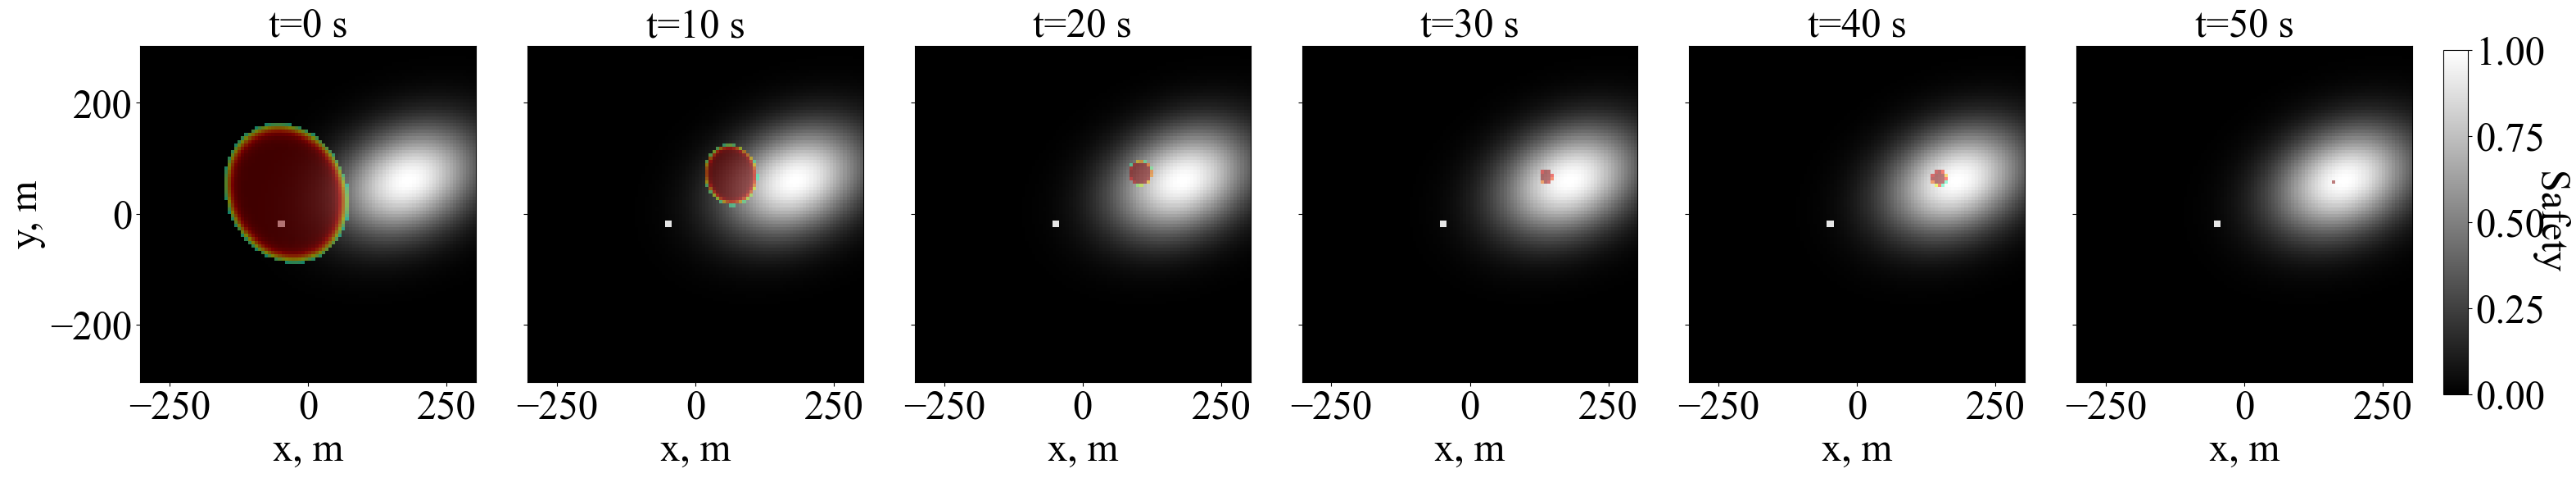

In [65]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=10.0, alpha=0.0)
hda_rs.solve_hda(x0_init, tof, T, dt)
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)

x0: [-120.    0. 1300.   10.    5.  -55. 1905.], tgo: 60.0
Initial guess: 1.643143892288208 sec for 1 solutions
Reach-steering HDA optimized single leg: 8.998929023742676 sec
x0: [ -64.48230208   26.28593425 1016.86328526   11.69775321    5.39567208
  -58.75239046 1891.8551782 ], tgo: 55.0
Initial guess: 1.6651642322540283 sec for 1 solutions
Reach-steering HDA optimized single leg: 6.620313405990601 sec
x0: [-2.12388259e+01  4.20992209e+01  7.62653231e+02  5.88296665e+00
  1.20370571e+00 -4.27556014e+01  1.86180827e+03], tgo: 50.0
Initial guess: 1.4156060218811035 sec for 1 solutions
Reach-steering HDA optimized single leg: 4.856674432754517 sec
x0: [-2.63655034e+00  4.12317535e+01  5.90960382e+02  1.86901051e+00
 -1.25130273e+00 -2.57688030e+01  1.83176852e+03], tgo: 45.0
Initial guess: 1.2914068698883057 sec for 1 solutions
Reach-steering HDA optimized single leg: 3.5746476650238037 sec
x0: [ 7.32666243e-01  3.27341946e+01  5.06327846e+02 -1.93326300e-01
 -1.83433871e+00 -7.96107231

C:\Users\ktomita3\AppData\Local\Temp\ipykernel_10304\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


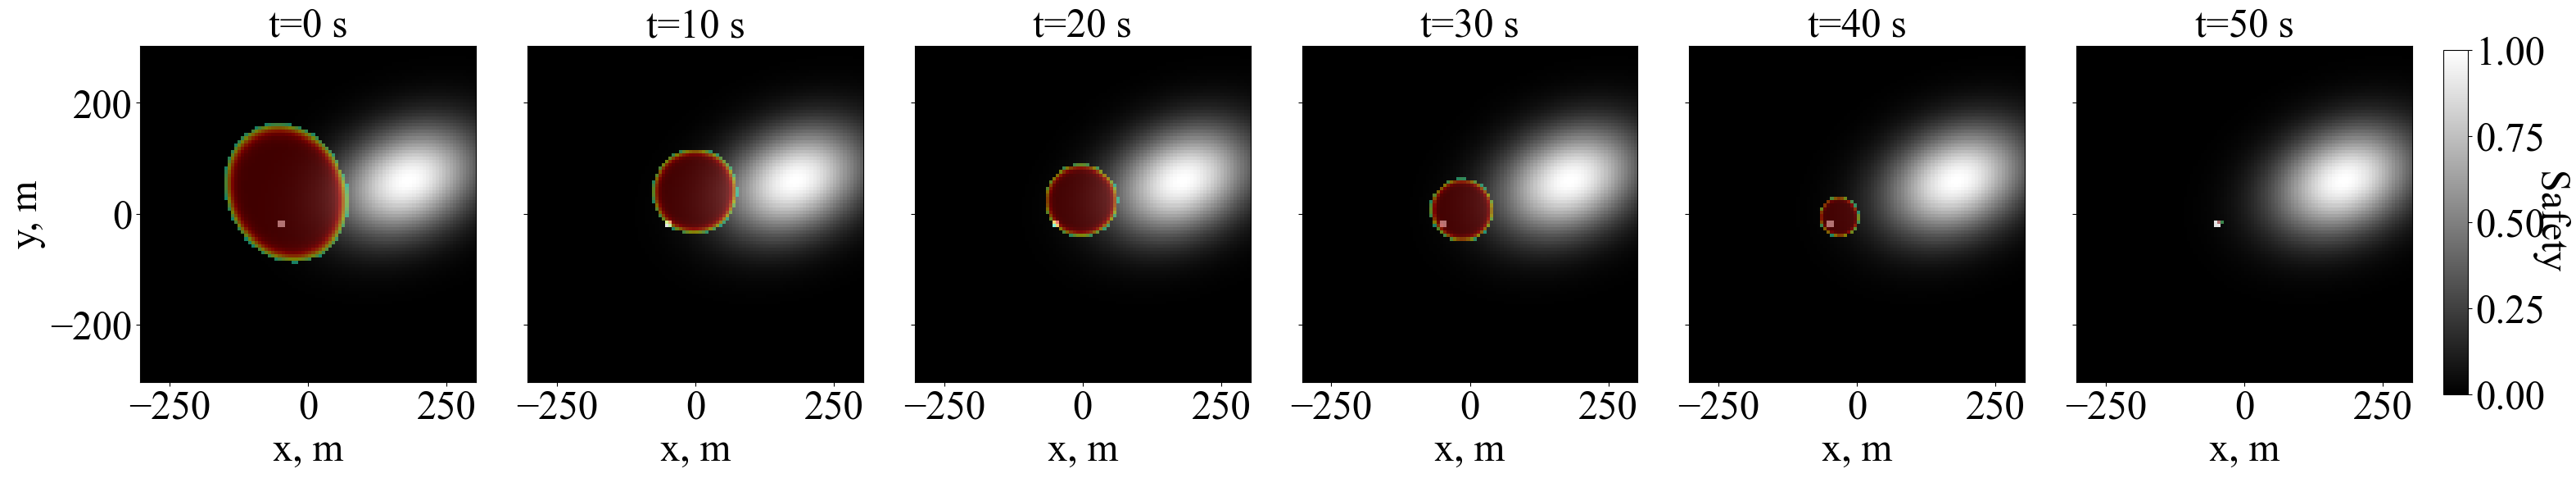

In [66]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=10.0, alpha=0.5)
hda_rs.solve_hda(x0_init, tof, T, dt)
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)

x0: [-120.    0. 1300.   10.    5.  -55. 1905.], tgo: 60.0
Initial guess: 1.7271034717559814 sec for 1 solutions
Reach-steering HDA optimized single leg: 12.487834215164185 sec
x0: [ -64.36477344   25.58552439 1016.86328526   11.73391586    5.18016135
  -58.75239046 1891.8551782 ], tgo: 55.0
Initial guess: 1.6123573780059814 sec for 1 solutions
Reach-steering HDA optimized single leg: 323.31642293930054 sec
x0: [ 3.56437325e+01  4.29818778e+01  7.52929496e+02  2.61436379e+01
 -1.70536369e+00 -4.67404371e+01  1.86180754e+03], tgo: 50.0
Initial guess: 1.3759722709655762 sec for 1 solutions
Reach-steering HDA optimized single leg: 13.460119247436523 sec
x0: [ 1.31372347e+02  3.77192805e+01  5.55015965e+02  1.27792473e+01
 -4.78007421e-01 -3.20648782e+01  1.83176779e+03], tgo: 45.0
Initial guess: 1.2216620445251465 sec for 1 solutions
Reach-steering HDA optimized single leg: 28.48195481300354 sec
x0: [ 1.80591330e+02  3.67194887e+01  4.37936993e+02  7.03791527e+00
  6.02943776e-02 -1.46453

C:\Users\ktomita3\AppData\Local\Temp\ipykernel_9080\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


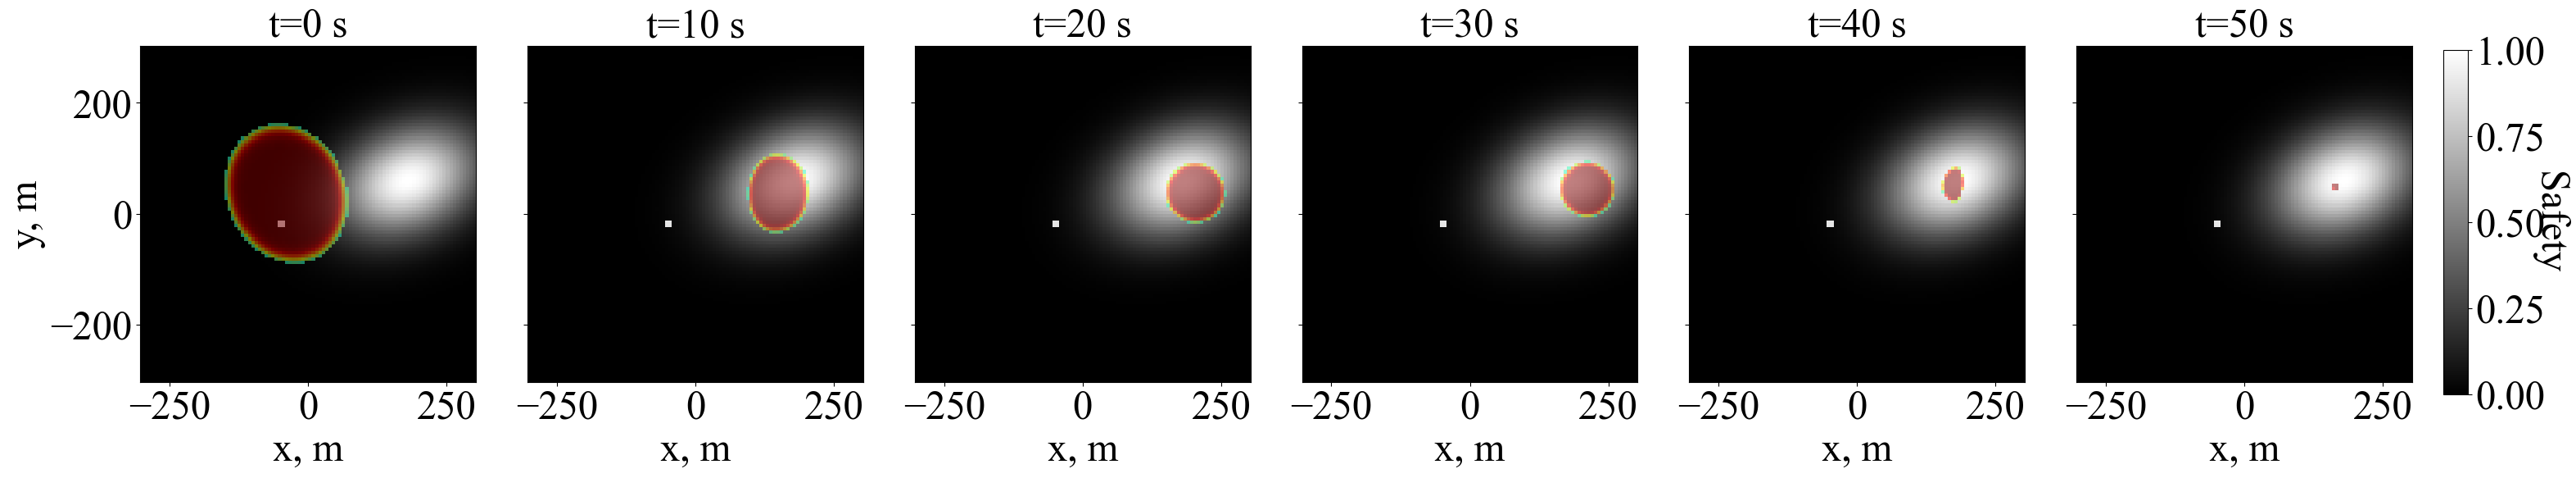

In [6]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=10.0, alpha=0.1)
hda_rs.solve_hda(x0_init, tof, T, dt)
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)

x0: [-120.    0. 1300.   10.    5.  -55. 1905.], tgo: 60.0
Initial guess: 1.8365299701690674 sec for 1 solutions
Reach-steering HDA optimized single leg: 2.6700339317321777 sec
x0: [ -77.70381377   20.11601853 1065.52952989    6.96598897    3.08169265
  -38.68977976 1874.95317985], tgo: 55.0
Initial guess: 1.5623326301574707 sec for 1 solutions
Reach-steering HDA optimized single leg: 2.257817268371582 sec
x0: [-4.98473839e+01  3.11826751e+01  9.14102351e+02  4.22579309e+00
  1.38149929e+00 -2.17803551e+01  1.84491021e+03], tgo: 50.0
Initial guess: 1.4032742977142334 sec for 1 solutions
Reach-steering HDA optimized single leg: 2.0289032459259033 sec
x0: [-3.47036162e+01  3.43100319e+01  8.48742870e+02  1.87988840e+00
 -9.27305742e-02 -4.26068609e+00  1.81487883e+03], tgo: 45.0
Initial guess: 1.297548532485962 sec for 1 solutions
Reach-steering HDA optimized single leg: 1.8393259048461914 sec
x0: [-2.78532461e+01  3.22875930e+01  8.25063528e+02  9.91064132e-01
 -6.32443695e-01 -7.043805

C:\Users\ktomita3\AppData\Local\Temp\ipykernel_10304\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


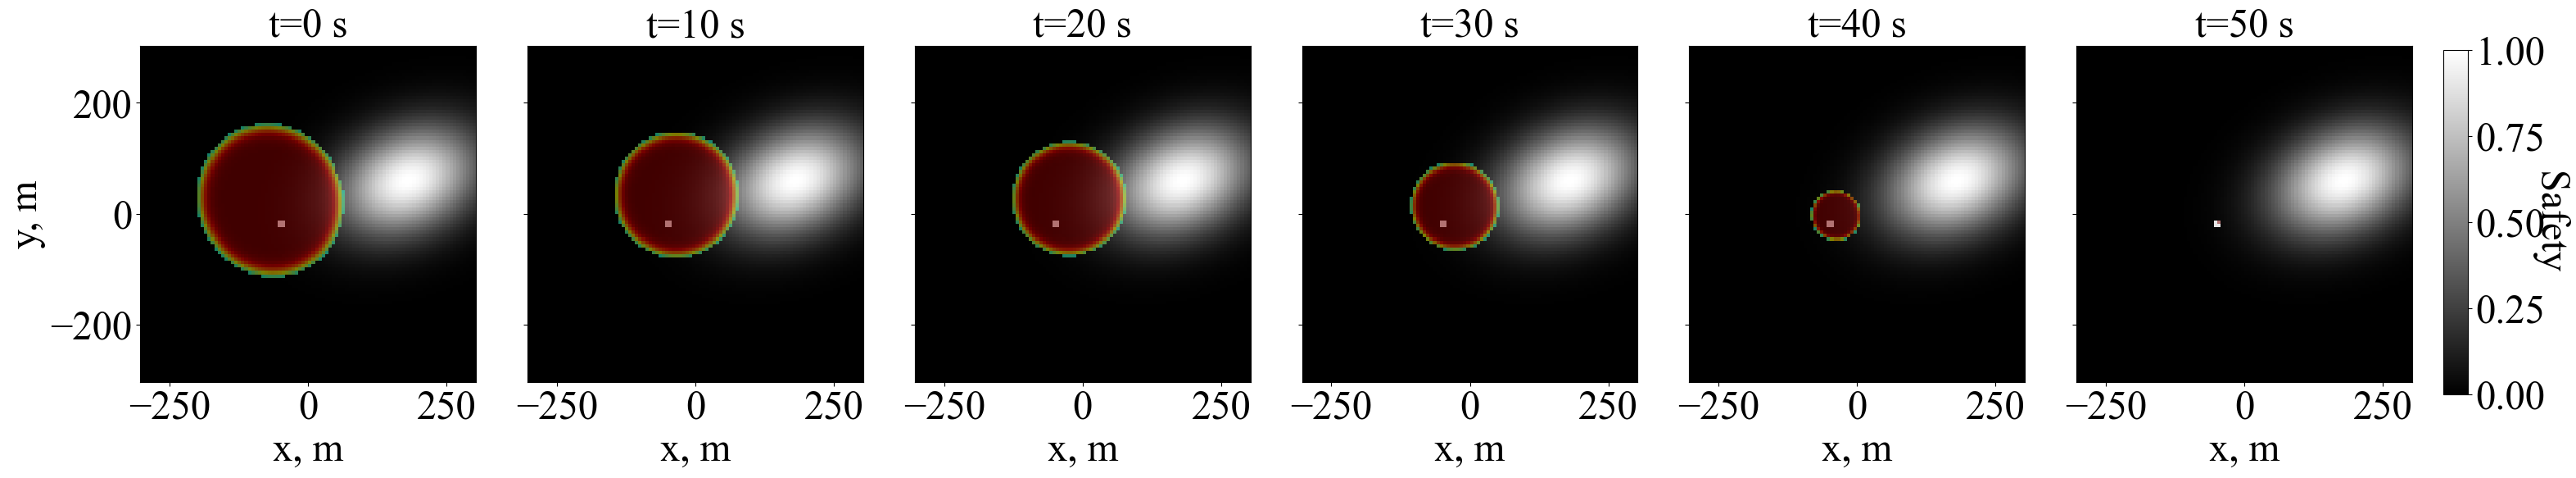

In [63]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=10.0, alpha=1.0)
hda_rs.solve_hda(x0_init, tof, T, dt)
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_10304\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


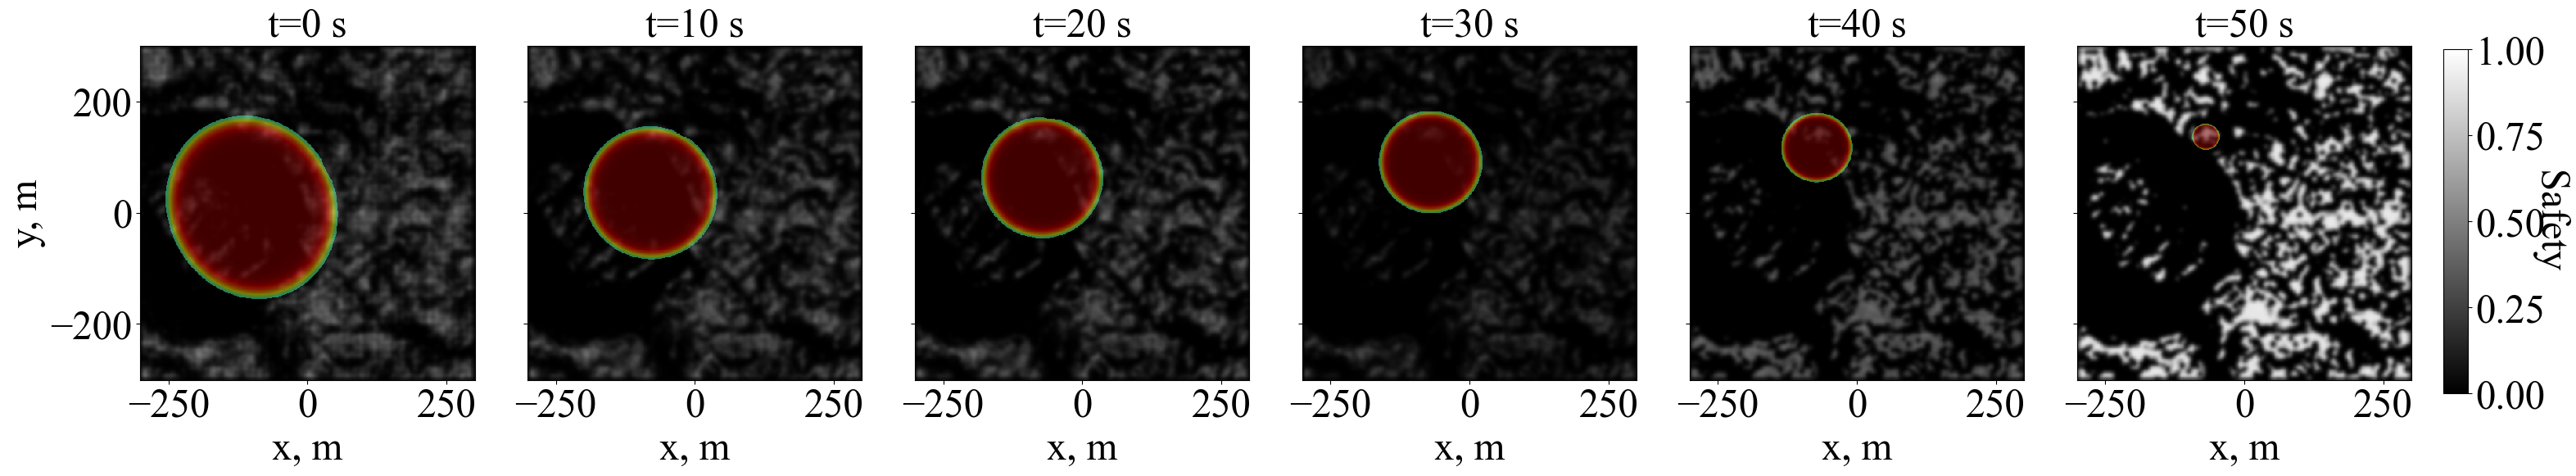

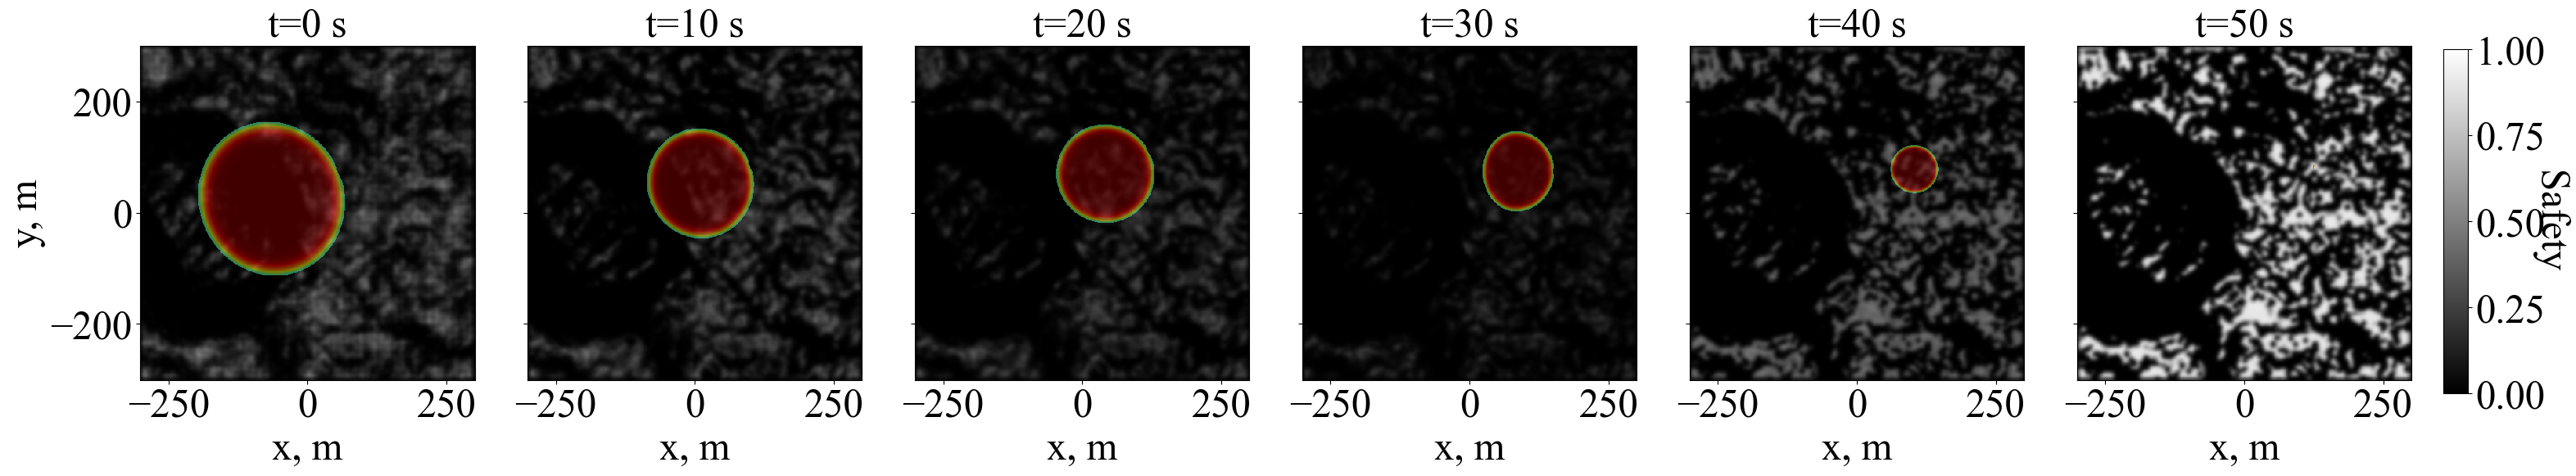

In [50]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)

fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)

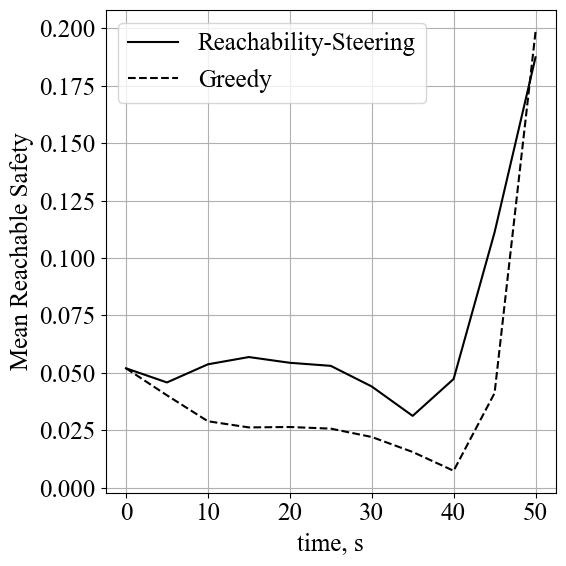

In [51]:
# font size
fontsize = 18
times = np.arange(len(hda_rs.mean_safety_list)) * T
plt.figure(figsize=(6, 6))
plt.plot(times, hda_rs.mean_safety_list, 'k-', label='Reachability-Steering')
plt.plot(times, hda_greedy.mean_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Mean Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
plt.savefig('../saved/fig/mean_reachable_safety.pdf')

In [ ]:
hda_greedy = HdaGreedy(lander, sfmap_model, nn_reach, border_sharpness=3.0)
hda_greedy.solve_hda(x0_init, tof, T, dt)

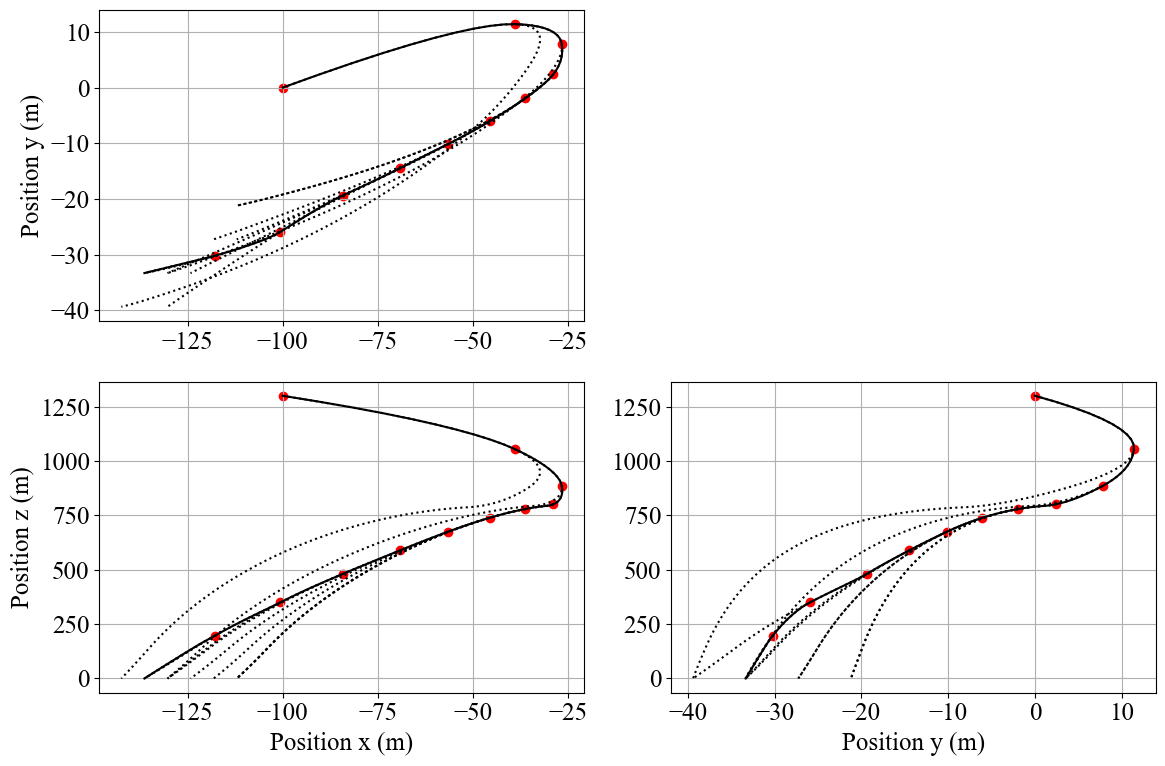

In [15]:
fig, ax = visualize_traj(hda_greedy)
fig.savefig('../saved/fig/traj_greedy.pdf', bbox_inches='tight')


In [ ]:
visualize_profiles(hda_greedy, lander)

In [ ]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)
#fig.savefig('../saved/fig/reachset_greeedy.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_greeedy.png', bbox_inches='tight', dpi=500)


In [ ]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=3.0,
                          itr_max=10000, ftol=1e-12, ctol=1e-8)
hda_rs.solve_hda(x0_init, tof, T, dt)

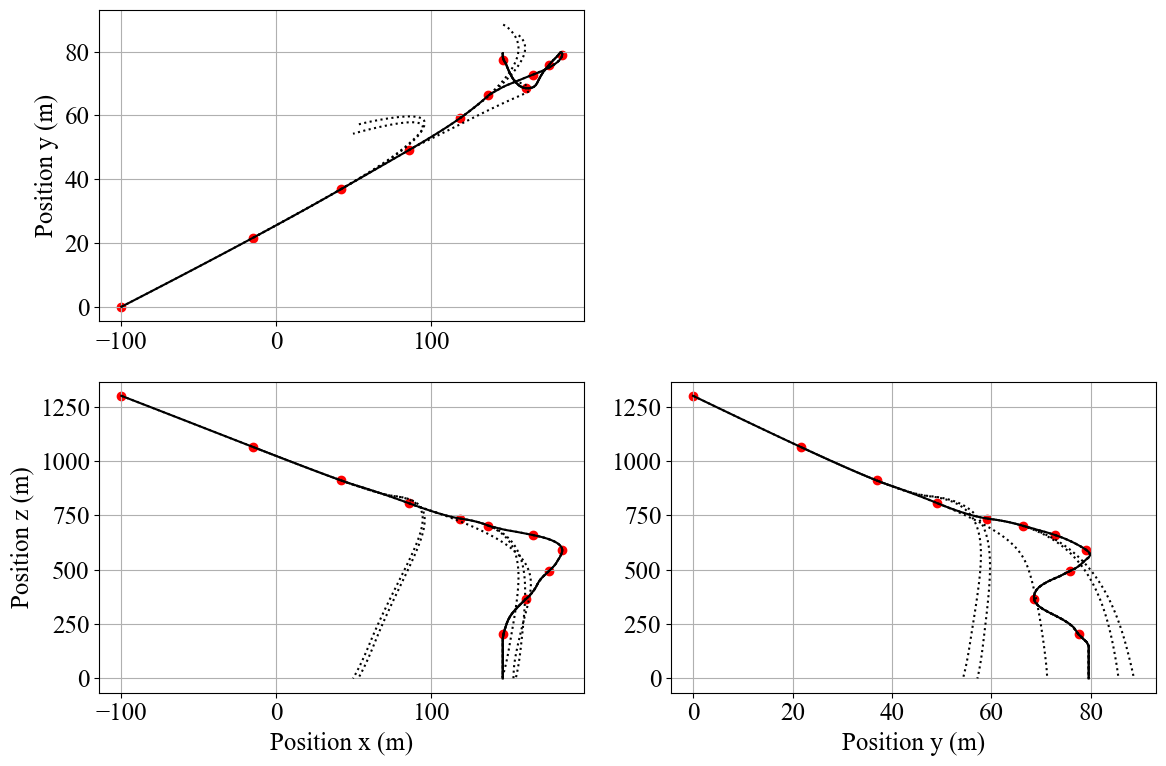

In [17]:
fig, ax = visualize_traj(hda_rs)
fig.savefig('../saved/fig/traj_rs.pdf', bbox_inches='tight')

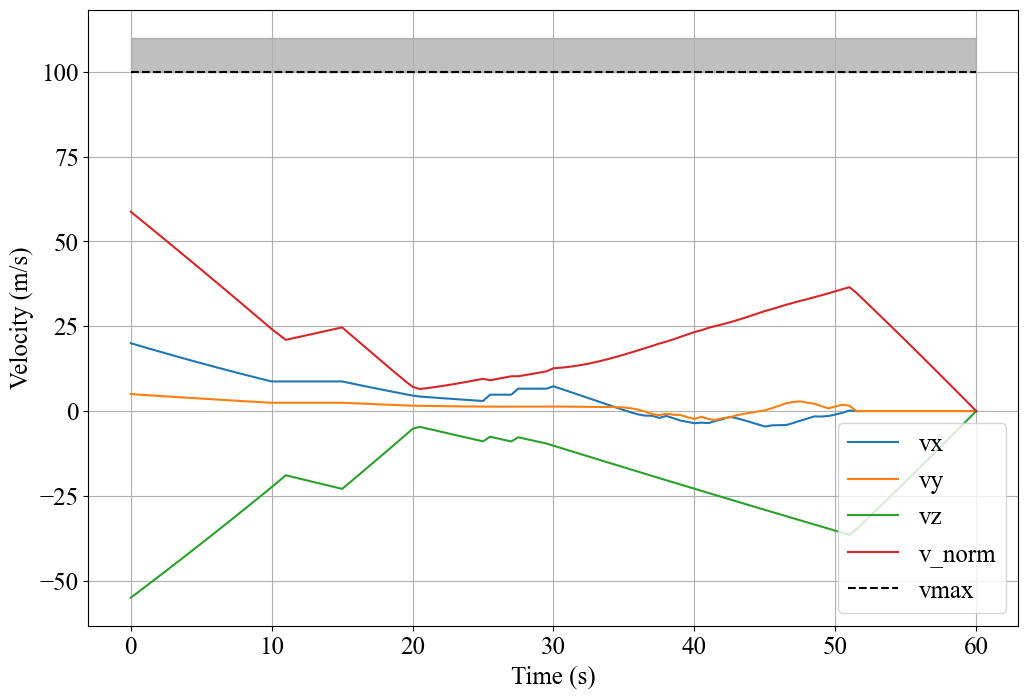

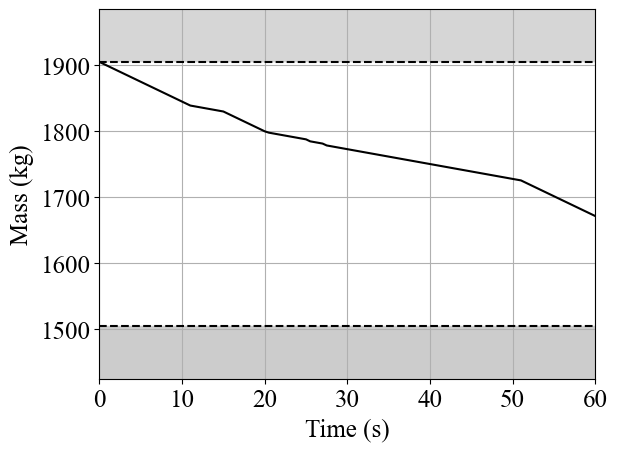

(120,)


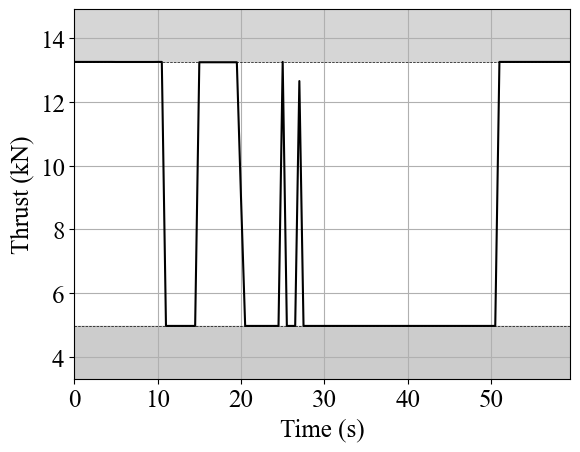

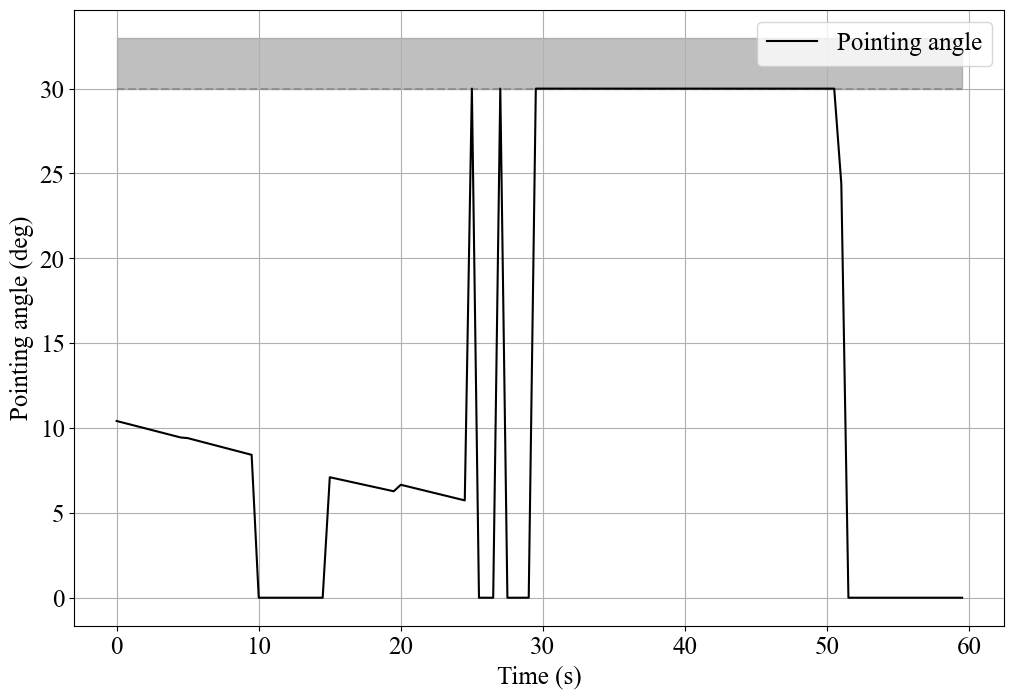

In [16]:
visualize_profiles(hda_rs, lander)

In [ ]:
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)
fig.savefig('../saved/fig/reachset_rs.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_rs.png', bbox_inches='tight', dpi=500)

In [ ]:
# font size
fontsize = 18
plt.figure(figsize=(6, 6))
plt.plot(np.arange(11), hda_rs.mean_safety_list, 'k-', label='Reachability-Steering')
plt.plot(np.arange(11), hda_greedy.mean_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Mean Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
plt.savefig('../saved/fig/mean_reachable_safety.pdf')